In [ ]:
# ===============================================================
# EXPERIMENT: MULTICLASS CLASSIFICATION
# Student Performance Level Analysis
# Models:
# 1. Decision Tree
# 2. Random Forest
# 3. Multinomial Logistic Regression
# 4. XGBoost
# 5. K-Nearest Neighbors
# ===============================================================


# ===============================================================
# STEP 1: Import Required Libraries
# ===============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# ===============================================================
# STEP 2: Load Dataset
# Replace path with your dataset location
# ===============================================================

data = pd.read_csv("/content/drive/MyDrive/ML LAB EXPERIMENTS/multiclass_classification_dataset_500_samples.csv")

print("First 5 rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())

First 5 rows:
   Study_Hours  Attendance_Percentage  Assignment_Score  Internal_Marks  \
0        22.48                  84.26             86.79           76.68   
1        19.31                  94.09             81.10           56.73   
2        23.24                  61.01             70.72           52.73   
3        27.62                  80.63             62.24           64.95   
4        18.83                  68.49             78.38           62.45   

  Participation Internet_Access Previous_Grade  Performance_Level  
0        Medium             Yes              B                  1  
1           Low             Yes              B                  1  
2        Medium             Yes              A                  0  
3           Low             Yes              C                  0  
4          High             Yes              B                  0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Col

In [ ]:
# ===============================================================
# STEP 3: Convert Target Variable to Performance Levels
# Example: Based on marks
# Low (<50), Medium (50-75), High (>75)
# ===============================================================

data["Performance_Level"] = pd.cut(
    data["Internal_Marks"],
    bins=[0, 50, 75, 100],
    labels=["Low", "Medium", "High"]
)

In [ ]:
# ===============================================================
# STEP 4: Encode Target Labels
# ===============================================================

label_encoder = LabelEncoder()
data["Performance_Level"] = label_encoder.fit_transform(data["Performance_Level"])


In [ ]:
# ===============================================================
# STEP 4: Encode Target Labels
# ===============================================================

label_encoder = LabelEncoder()
data["Performance_Level"] = label_encoder.fit_transform(data["Performance_Level"])


In [ ]:
# ===============================================================
# STEP 5: Separate Features and Target
# ===============================================================

X = data.drop(["Performance_Level"], axis=1)
y = data["Performance_Level"]

In [ ]:
# ===============================================================
# STEP 6: Handle Categorical Variables (if present)
# ===============================================================

X = pd.get_dummies(X)

In [ ]:
# ===============================================================
# STEP 7: Train-Test Split
# ===============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
# ===============================================================
# STEP 8: Feature Scaling
# ===============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




In [ ]:

# ===============================================================
# STEP 9: Initialize Models
# ===============================================================

models = {

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Logistic Regression": LogisticRegression(
        multi_class="multinomial",
        max_iter=1000
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "XGBoost": XGBClassifier(
        eval_metric="mlogloss"
    )
}


In [ ]:
# ===============================================================
# STEP 10: Train Models and Store Predictions
# ===============================================================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test, y_pred, average="weighted"
    )

    rec = recall_score(
        y_test, y_pred, average="weighted"
    )

    f1_weighted = f1_score(
        y_test, y_pred, average="weighted"
    )

    f1_macro = f1_score(
        y_test, y_pred, average="macro"
    )

    f1_micro = f1_score(
        y_test, y_pred, average="micro"
    )

    results.append([
        name,
        acc,
        prec,
        rec,
        f1_weighted,
        f1_macro,
        f1_micro
    ])


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# ===============================================================
# STEP 11: Display Evaluation Metrics
# ===============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Weighted",
        "F1 Macro",
        "F1 Micro"
    ]
)

print("\nModel Comparison:")
print(results_df)



Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Weighted  F1 Macro  \
0        Decision Tree  1.000000   1.000000  1.000000     1.000000  1.000000   
1        Random Forest  0.980000   0.980682  0.980000     0.979507  0.971997   
2  Logistic Regression  0.960000   0.962637  0.960000     0.959303  0.950000   
3                  KNN  0.653333   0.669445  0.653333     0.609678  0.510885   
4              XGBoost  1.000000   1.000000  1.000000     1.000000  1.000000   

   F1 Micro  
0  1.000000  
1  0.980000  
2  0.960000  
3  0.653333  
4  1.000000  


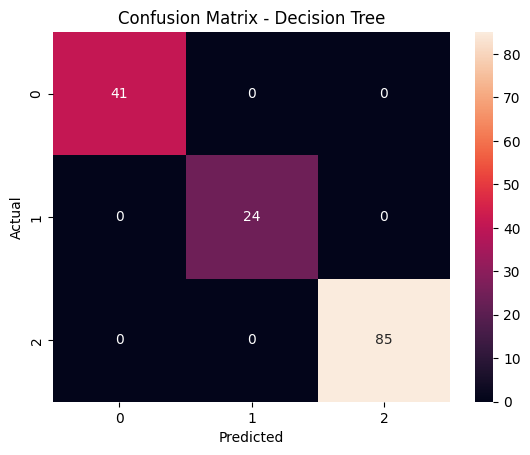

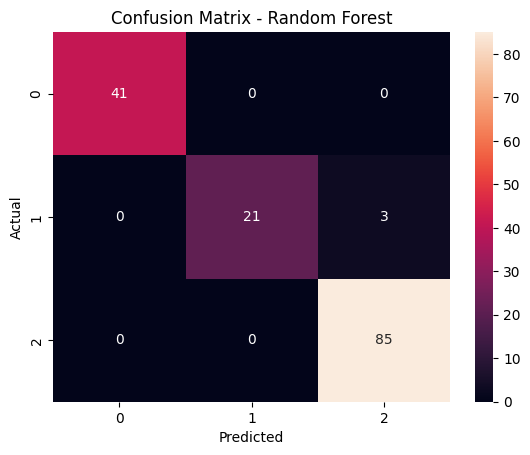

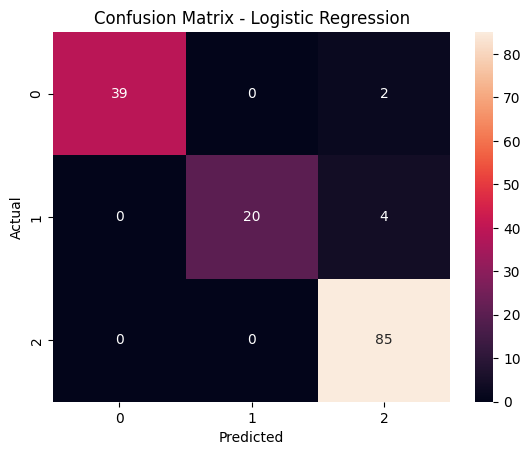

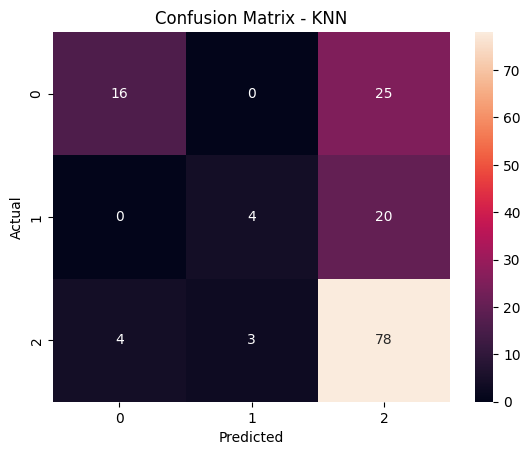

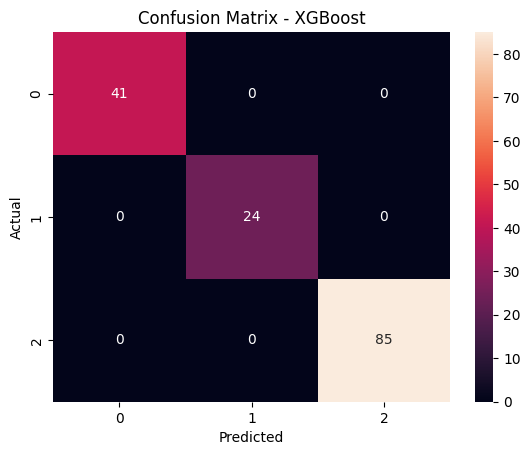

In [ ]:
# ===============================================================
# STEP 12: Confusion Matrix for Each Model
# ===============================================================

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title("Confusion Matrix - " + name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [ ]:
# ===============================================================
# STEP 13: Classification Report
# ===============================================================

for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n================================")
    print("Model:", name)
    print("================================")

    print(classification_report(y_test, y_pred))


Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        85

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150


Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      0.88      0.93        24
           2       0.97      1.00      0.98        85

    accuracy                           0.98       150
   macro avg       0.99      0.96      0.97       150
weighted avg       0.98      0.98      0.98       150


Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        41
           1       1.00      0.83      0.91        24
   

In [ ]:
# ===============================================================
# STEP 14: ROC-AUC Score (Multiclass)
# ===============================================================

for name, model in models.items():

    if hasattr(model, "predict_proba"):

        y_prob = model.predict_proba(X_test)

        roc_auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr"
        )

        print(name, "ROC-AUC:", roc_auc)

Decision Tree ROC-AUC: 1.0
Random Forest ROC-AUC: 1.0
Logistic Regression ROC-AUC: 0.9990626887672001
KNN ROC-AUC: 0.7841340671874656
XGBoost ROC-AUC: 1.0
